# The June-2025 War and New Bond Issuance — Seasonality & Similarity

**Question.** Did the June-2025 conflict (US + Israel strikes on Iran, the "12-day war", ~13–24 Jun 2025)
interfere with new debt issuance? We (1) establish the **multi-year seasonality** of issuance, (2) test
whether **2026 (this year, YTD)** departs from that norm — scoring similarity with **silhouette /
clustering** — and (3) run an **event study** of the war window itself.

**Data.** Reconstructed primary-issuance calendar from the 7-CSV snapshot in this folder (reusing
`load_merge.build_security_table`). Each bond contributes its issue date + issuer country.

> **Caveats.** This is a *snapshot* of currently-outstanding bonds, so history is **survivorship-biased**
> (reliable post-2019; matured / very short-dated paper is under-counted). Issuance also **grew ~4× since
> 2019**, so everything below compares *shares / shapes*, never raw counts. Israel is **thin** (~40–85
> bonds/yr) — its event-study numbers are indicative, not statistically decisive.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # import the local data layer
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram
from load_merge import build_security_table

# -------- parameters (editable) --------
WAR_START, WAR_END = pd.Timestamp("2025-06-13"), pd.Timestamp("2025-06-24")
WAR_MONTH = pd.Timestamp("2025-06-01")
FOCUS_YEAR   = 2026
BASELINE_YEARS = list(range(2016, 2025))           # seasonal norm (pre the war year)
SPOTLIGHT    = {"Global": None, "US": "Estados Unidos", "Israel": "Israel"}
START_YEAR   = 2011
RESULTS = "results_war_seasonality"; os.makedirs(RESULTS, exist_ok=True)

# -------- validated categorical/sequential/diverging palette (dataviz skill) --------
C_BLUE, C_ORANGE, C_RED = "#2a78d6", "#eb6834", "#e34948"
INK, INK2, MUTED, GRID, BASE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
WARN = "#fab219"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#eef5fd", "#9ec5f4", "#3987e5", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_br", [C_BLUE, "#9ec5f4", "#f0efec", "#f0a6a5", C_RED])
SPOT_COLOR = {"Global": MUTED, "US": C_BLUE, "Israel": C_RED}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
})
def save(fig, name): fig.savefig(os.path.join(RESULTS, name), dpi=140, bbox_inches="tight")
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
print("palette + params ready")

palette + params ready


## 1 · Load and prepare the issuance history

In [2]:
t = build_security_table()
t = t[t["issue_date"].notna()].copy()
t["year"]  = t["issue_date"].dt.year
t["month"] = t["issue_date"].dt.month
t = t[t["year"] >= START_YEAR]

def detect_last_complete_month(df, year):
    c = df[df.year == year].groupby("month").size().reindex(range(1, 13), fill_value=0)
    for m in range(2, 13):
        base = c.loc[max(1, m-3):m-1]; base = base[base > 0].mean()
        if c.loc[m] == 0 or (base and c.loc[m] < 0.4 * base):
            return m - 1
    return 12

CUT = detect_last_complete_month(t, FOCUS_YEAR)
cm = (t.groupby(["year","month"]).size().unstack("month")
        .reindex(columns=range(1,13)).fillna(0).astype(int))
complete_years = [y for y in cm.index if (cm.loc[y] > 0).all() and y <= 2025]
print(f"{len(t):,} issuance events, {t.year.min()}–{t.year.max()};  "
      f"{FOCUS_YEAR} complete through month {CUT} ({MONTHS[CUT-1]})")
print("complete calendar years:", complete_years)

27,282 issuance events, 2011–2026;  2026 complete through month 7 (Jul)
complete calendar years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


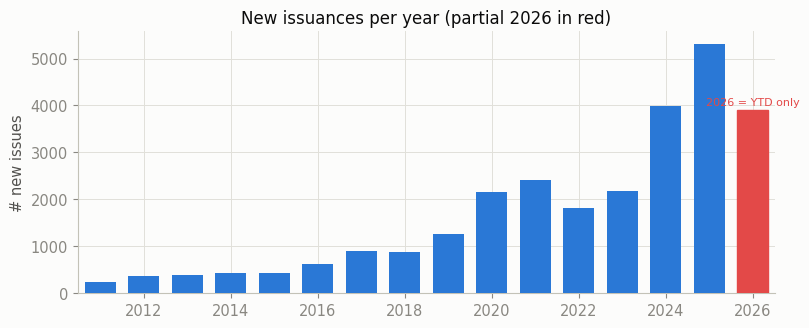

In [3]:
# issuance per year (level + trend context)
yr = t.groupby("year").size()
fig, ax = plt.subplots(figsize=(9, 3.4))
bars = ax.bar(yr.index, yr.values, color=C_BLUE, width=0.72, zorder=3)
bars[list(yr.index).index(FOCUS_YEAR)].set_color(C_RED)   # focus year
ax.set_title("New issuances per year (partial 2026 in red)")
ax.set_ylabel("# new issues"); ax.margins(x=0.01)
ax.annotate("2026 = YTD only", (FOCUS_YEAR, yr.loc[FOCUS_YEAR]), textcoords="offset points",
            xytext=(0, 4), ha="center", fontsize=8, color=C_RED)
save(fig, "fig1_issuance_per_year.png"); plt.show()

## 2 · Seasonality of issuance

Because issuance grew ~4×, each year is normalized to **monthly shares** (sum to 1) so we compare the
*shape* of the year, not its level. The **seasonal index** is the median share per calendar month across
the baseline years.

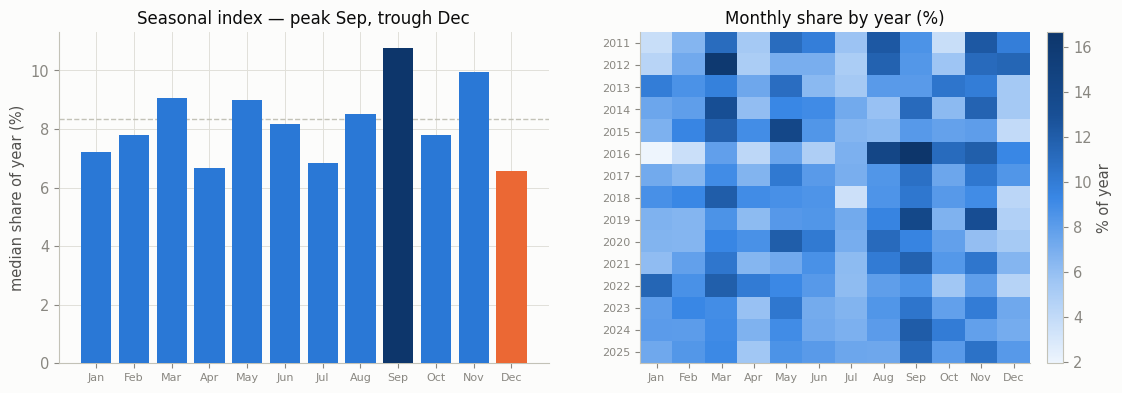

seasonal index (%): {'Jan': np.float64(7.2), 'Feb': np.float64(7.8), 'Mar': np.float64(9.0), 'Apr': np.float64(6.7), 'May': np.float64(9.0), 'Jun': np.float64(8.2), 'Jul': np.float64(6.9), 'Aug': np.float64(8.5), 'Sep': np.float64(10.8), 'Oct': np.float64(7.8), 'Nov': np.float64(10.0), 'Dec': np.float64(6.6)}


In [4]:
shares_full = cm.loc[complete_years].div(cm.loc[complete_years].sum(1), axis=0)
seasonal_index = shares_full.loc[[y for y in BASELINE_YEARS if y in shares_full.index]].median()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios":[1.15,1]})
# (a) seasonal index bars, peak/trough highlighted
si = seasonal_index.values*100
cols = [C_BLUE]*12
cols[int(np.argmax(si))] = "#0d366b"; cols[int(np.argmin(si))] = C_ORANGE
ax[0].bar(range(1,13), si, color=cols, zorder=3)
ax[0].axhline(100/12, color=BASE, ls="--", lw=1)
ax[0].set_xticks(range(1,13)); ax[0].set_xticklabels(MONTHS, fontsize=8)
ax[0].set_ylabel("median share of year (%)")
ax[0].set_title(f"Seasonal index — peak {MONTHS[int(np.argmax(si))]}, trough {MONTHS[int(np.argmin(si))]}")
# (b) year×month share heatmap (sequential)
hm = shares_full*100
im = ax[1].imshow(hm.values, aspect="auto", cmap=SEQ)
ax[1].set_xticks(range(12)); ax[1].set_xticklabels(MONTHS, fontsize=8)
ax[1].set_yticks(range(len(hm.index))); ax[1].set_yticklabels(hm.index, fontsize=8)
ax[1].set_title("Monthly share by year (%)"); ax[1].grid(False)
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04, label="% of year")
save(fig, "fig2_seasonality.png"); plt.show()
print("seasonal index (%):", dict(zip(MONTHS, si.round(1))))

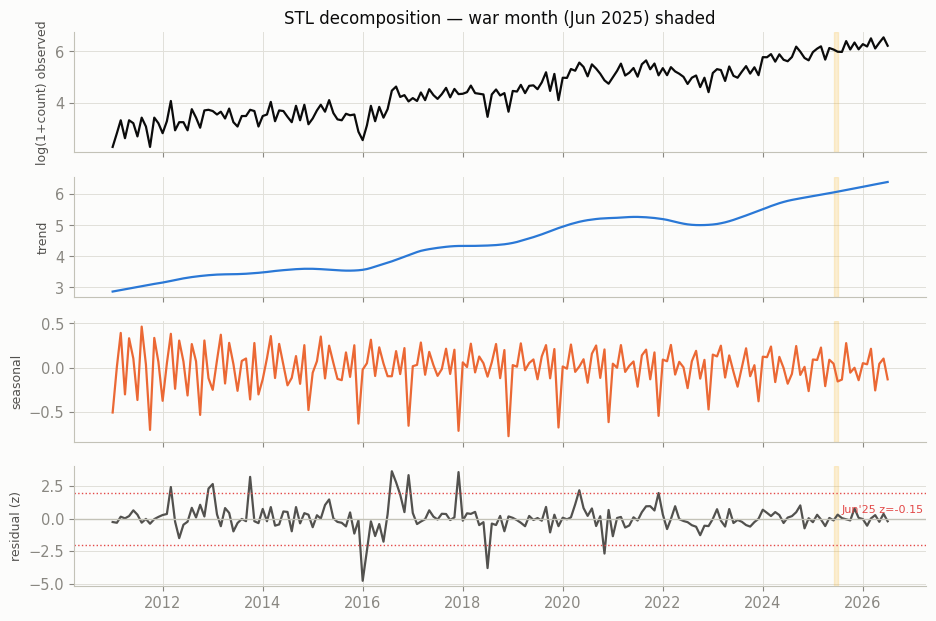

Global issuance residual at war month = -0.15 sigma  -> no material global anomaly


In [5]:
# STL decomposition of the monthly log-count series (removes trend+season -> residual anomalies)
ms = t.groupby(t.issue_date.dt.to_period("M")).size()
ms = ms[ms.index <= pd.Period(f"{FOCUS_YEAR}-{CUT:02d}")]
ms.index = ms.index.to_timestamp(); ms = ms.asfreq("MS").fillna(0)
stl = STL(np.log1p(ms), period=12, robust=True).fit()
zr = stl.resid / stl.resid.std()

fig, ax = plt.subplots(4, 1, figsize=(11, 7.2), sharex=True)
for a, (series, name, col) in zip(ax, [
        (stl.observed, "log(1+count) observed", INK), (stl.trend, "trend", C_BLUE),
        (stl.seasonal, "seasonal", C_ORANGE), (zr, "residual (z)", INK2)]):
    a.plot(series.index, series.values, color=col, lw=1.6)
    a.set_ylabel(name, fontsize=9); a.axvspan(WAR_MONTH, WAR_MONTH+pd.offsets.MonthEnd(1),
                                              color=WARN, alpha=0.18)
ax[3].axhline(0, color=BASE, lw=1); ax[3].axhline(2, color=C_RED, ls=":", lw=1); ax[3].axhline(-2, color=C_RED, ls=":", lw=1)
ax[0].set_title("STL decomposition — war month (Jun 2025) shaded")
zwar = float(zr.get(WAR_MONTH, np.nan))
ax[3].annotate(f"Jun'25 z={zwar:+.2f}", (WAR_MONTH, zwar), textcoords="offset points",
               xytext=(6, 6), fontsize=8, color=C_RED)
save(fig, "fig3_stl.png"); plt.show()
print(f"Global issuance residual at war month = {zwar:+.2f} sigma  ->",
      "no material global anomaly" if abs(zwar) < 1 else "anomaly")

## 3 · Is 2026 (this year, YTD) unusual vs the seasonal norm?

Compare 2026's Jan–cutoff monthly shares to the baseline distribution (per-month z-score), and its cumulative
issuance path against every prior year's same-months path.

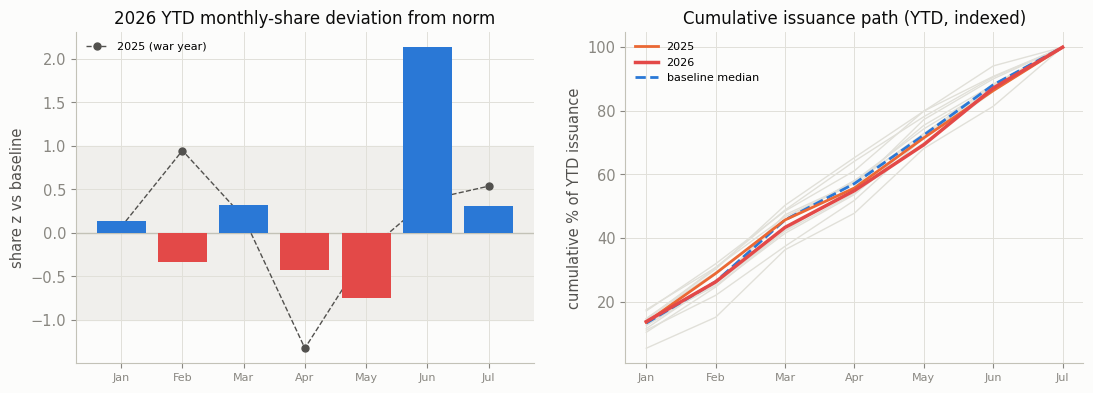

2026 YTD share z by month: {'Jan': np.float64(0.14), 'Feb': np.float64(-0.34), 'Mar': np.float64(0.32), 'Apr': np.float64(-0.43), 'May': np.float64(-0.75), 'Jun': np.float64(2.13), 'Jul': np.float64(0.3)}


In [6]:
ytd = cm.loc[:, 1:CUT]
ytd_years = [y for y in ytd.index if (ytd.loc[y] > 0).any() and y >= 2013]
ytd_shape = ytd.loc[ytd_years].div(ytd.loc[ytd_years].sum(1), axis=0)
base_ytd = ytd_shape.loc[[y for y in BASELINE_YEARS if y in ytd_years]]
med, sd = base_ytd.median(), base_ytd.std()
z_focus = (ytd_shape.loc[FOCUS_YEAR] - med) / sd
z_2025  = (ytd_shape.loc[2025]     - med) / sd

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
# (a) 2026 monthly-share z vs norm band (diverging by sign)
mm = list(range(1, CUT+1))
colz = [C_BLUE if v >= 0 else C_RED for v in z_focus.values]
ax[0].axhspan(-1, 1, color="#f0efec", zorder=0); ax[0].axhline(0, color=BASE, lw=1)
ax[0].bar(mm, z_focus.values, color=colz, zorder=3)
ax[0].plot(mm, z_2025.values, "o--", color=INK2, ms=5, lw=1, label="2025 (war year)")
ax[0].set_xticks(mm); ax[0].set_xticklabels([MONTHS[m-1] for m in mm], fontsize=8)
ax[0].set_ylabel("share z vs baseline"); ax[0].legend(fontsize=8, frameon=False)
ax[0].set_title(f"{FOCUS_YEAR} YTD monthly-share deviation from norm")
# (b) cumulative YTD paths (gray context + highlights)
cum = ytd.loc[ytd_years, 1:CUT].cumsum(1).div(ytd.loc[ytd_years, 1:CUT].sum(1), axis=0)*100
for y in ytd_years:
    if y in (FOCUS_YEAR, 2025): continue
    ax[1].plot(mm, cum.loc[y].values, color=GRID, lw=1, zorder=1)
ax[1].plot(mm, cum.loc[2025].values, color=C_ORANGE, lw=2, label="2025", zorder=3)
ax[1].plot(mm, cum.loc[FOCUS_YEAR].values, color=C_RED, lw=2.5, label="2026", zorder=4)
med_path = cum.loc[[y for y in BASELINE_YEARS if y in ytd_years]].median()
ax[1].plot(mm, med_path.values, color=C_BLUE, lw=2, ls="--", label="baseline median", zorder=2)
ax[1].set_xticks(mm); ax[1].set_xticklabels([MONTHS[m-1] for m in mm], fontsize=8)
ax[1].set_ylabel("cumulative % of YTD issuance"); ax[1].legend(fontsize=8, frameon=False)
ax[1].set_title("Cumulative issuance path (YTD, indexed)")
save(fig, "fig4_focus_year.png"); plt.show()
print(f"{FOCUS_YEAR} YTD share z by month:", dict(zip([MONTHS[m-1] for m in mm], z_focus.round(2).values)))

## 4 · Silhouette — how similar is this year to prior years?

Each year is a point in "seasonal-shape" space (its YTD monthly-share vector). We cluster the years and
read 2026's **silhouette** (how well it fits its cluster vs the next-nearest one) plus its nearest-neighbour
years. A high positive silhouette + small distance ⇒ 2026 is a *typical* year; a low/negative one ⇒ outlier.

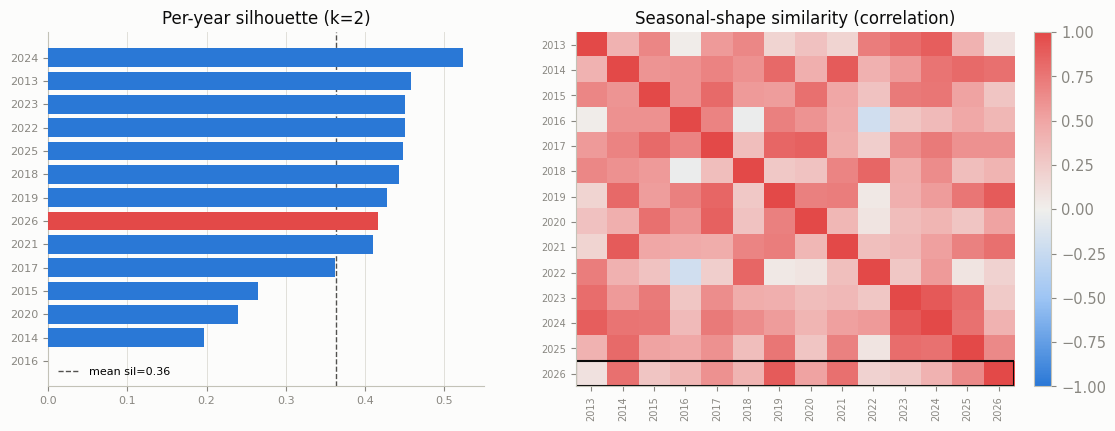

silhouette scan {k:score}: {2:0.364, 3:0.186, 4:0.193, 5:0.221, 6:0.218}  -> best k=2
2026: cluster 0, silhouette +0.416, atypicality percentile 36% (1=most unusual)
co-clusters with 2025 (war year): True
nearest years: [(2019, 1.21), (2021, 2.12), (2017, 2.44)]
most similar by correlation: {2019: 0.9, 2014: 0.79, 2021: 0.78}


In [7]:
X = ytd_shape.values
Xs = StandardScaler().fit_transform(X)
scan = {k: silhouette_score(Xs, KMeans(k, n_init=10, random_state=0).fit_predict(Xs)) for k in range(2, 7)}
bestk = max(scan, key=scan.get)
km = KMeans(bestk, n_init=10, random_state=0).fit(Xs)
sil = pd.Series(silhouette_samples(Xs, km.labels_), index=ytd_years)
lab = pd.Series(km.labels_, index=ytd_years)
D = pd.DataFrame(np.linalg.norm(Xs[:,None]-Xs[None], axis=2), index=ytd_years, columns=ytd_years)
nn = D.loc[FOCUS_YEAR].drop(FOCUS_YEAR).sort_values()
mean_d = D.apply(lambda r: r.drop(r.name).mean(), axis=1)
typ_pct = (mean_d < mean_d.loc[FOCUS_YEAR]).mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios":[1,1.1]})
# (a) per-year silhouette, 2026 highlighted
order = sil.sort_values().index
palc = [C_BLUE, C_ORANGE, "#1baf7a", C_RED]
cols = [C_RED if y == FOCUS_YEAR else palc[lab[y] % len(palc)] for y in order]
ax[0].barh([str(y) for y in order], sil.loc[order].values, color=cols, zorder=3)
ax[0].axvline(scan[bestk], color=INK2, ls="--", lw=1, label=f"mean sil={scan[bestk]:.2f}")
ax[0].set_title(f"Per-year silhouette (k={bestk})"); ax[0].legend(fontsize=8, frameon=False)
ax[0].tick_params(labelsize=8); ax[0].grid(axis="y", visible=False)
# (b) year×year similarity (correlation of monthly shapes)
corr = ytd_shape.T.corr()
im = ax[1].imshow(corr.values, cmap=DIV, vmin=-1, vmax=1, aspect="auto")
ax[1].set_xticks(range(len(corr))); ax[1].set_xticklabels(corr.index, rotation=90, fontsize=7)
ax[1].set_yticks(range(len(corr))); ax[1].set_yticklabels(corr.index, fontsize=7)
fi = list(corr.index).index(FOCUS_YEAR)
ax[1].add_patch(plt.Rectangle((-.5, fi-.5), len(corr), 1, fill=False, edgecolor=INK, lw=1.5))
ax[1].set_title("Seasonal-shape similarity (correlation)"); ax[1].grid(False)
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
save(fig, "fig5_silhouette.png"); plt.show()

print(f"silhouette scan {{k:score}}: {{{', '.join(f'{k}:{v:.3f}' for k,v in scan.items())}}}  -> best k={bestk}")
print(f"{FOCUS_YEAR}: cluster {lab.loc[FOCUS_YEAR]}, silhouette {sil.loc[FOCUS_YEAR]:+.3f}, "
      f"atypicality percentile {typ_pct:.0%} (1=most unusual)")
print(f"co-clusters with 2025 (war year): {lab.loc[2025]==lab.loc[FOCUS_YEAR]}")
print(f"nearest years: {[(int(y), round(d,2)) for y,d in nn.head(3).items()]}")
print(f"most similar by correlation: {corr.loc[FOCUS_YEAR].drop(FOCUS_YEAR).sort_values(ascending=False).head(3).round(2).to_dict()}")

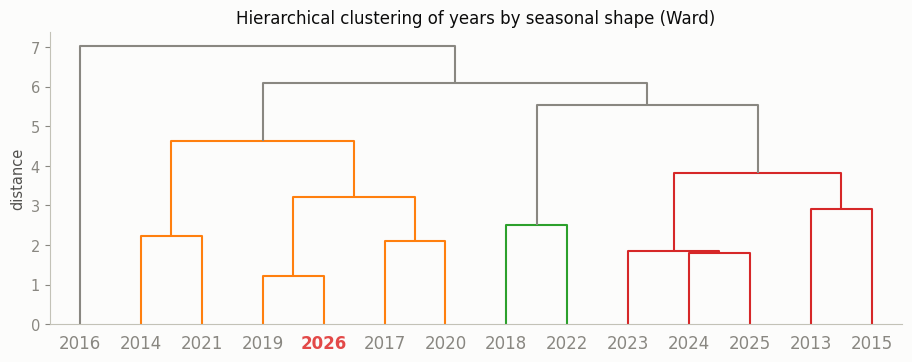

In [8]:
# hierarchical view (Ward) for the same seasonal-shape features
fig, ax = plt.subplots(figsize=(11, 3.8))
Z = linkage(Xs, method="ward")
dendrogram(Z, labels=[str(y) for y in ytd_years], ax=ax,
           color_threshold=0.7*Z[:,2].max(), above_threshold_color=MUTED)
for lbl in ax.get_xticklabels():
    if lbl.get_text() == str(FOCUS_YEAR): lbl.set_color(C_RED); lbl.set_fontweight("bold")
ax.set_title("Hierarchical clustering of years by seasonal shape (Ward)")
ax.set_ylabel("distance"); ax.grid(False)
save(fig, "fig6_dendrogram.png"); plt.show()

## 5 · Event study — the war window itself (June 2025)

The war hit in June 2025, so its direct footprint is a 2025 event. To strip out the 4× growth trend we
use **share of each issuer's own annual issuance** (detrended), comparing the Jun+Jul-2025 window and the
Sep-2025 rebound to each series' own seasonal norm.

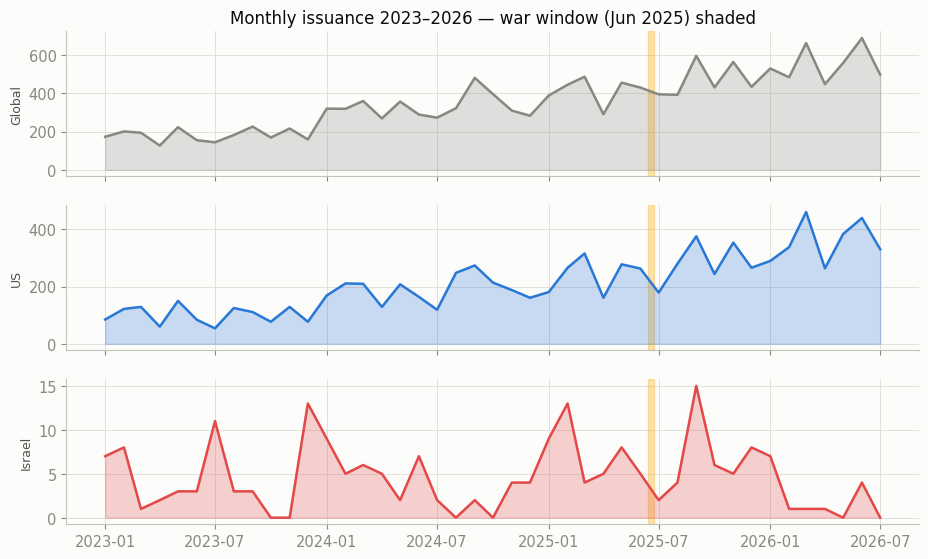

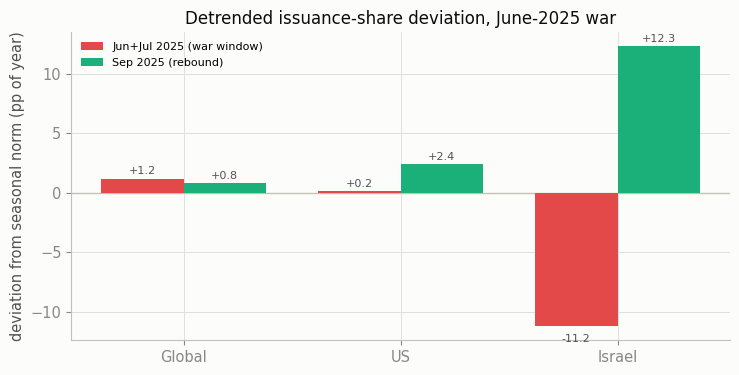

War-window share deviation:  Israel -11.2pp   global-ex-Israel +1.2pp   DiD = -12.4pp
Israel 2025 monthly issues: [9, 13, 4, 5, 8, 5, 2, 4, 15, 6, 5, 8]


In [9]:
def monthly(country, lo="2023-01", hi=None):
    d = t if country is None else t[t.country == country]
    s = d.groupby(d.issue_date.dt.to_period("M")).size()
    idx = pd.period_range(lo, hi or f"{FOCUS_YEAR}-{CUT:02d}", freq="M")
    return s.reindex(idx, fill_value=0)

# (a) small multiples: global / US / Israel monthly, war shaded (own y-scale each -> no dual axis)
fig, ax = plt.subplots(3, 1, figsize=(11, 6.4), sharex=True)
for a, (nm, ctry) in zip(ax, SPOTLIGHT.items()):
    s = monthly(ctry); x = s.index.to_timestamp()
    a.fill_between(x, s.values, color=SPOT_COLOR[nm], alpha=0.25, zorder=2)
    a.plot(x, s.values, color=SPOT_COLOR[nm], lw=1.8, zorder=3)
    a.axvspan(WAR_START, WAR_END, color=WARN, alpha=0.35)
    a.set_ylabel(nm, fontsize=9)
ax[0].set_title("Monthly issuance 2023–2026 — war window (Jun 2025) shaded")
save(fig, "fig7_event_series.png"); plt.show()

# (b) detrended share-of-own-year deviations in the war window + Sep rebound
def share_matrix(d, years):
    by = d.groupby(["year","month"]).size().unstack("month").reindex(columns=range(1,13)).fillna(0)
    by = by.reindex(years).fillna(0); return by.div(by.sum(1).replace(0, np.nan), axis=0)
evt_years = [y for y in complete_years if y >= 2018]; base = [y for y in evt_years if y <= 2024]
rows = {}
for nm, ctry in SPOTLIGHT.items():
    sh = share_matrix(t if ctry is None else t[t.country == ctry], evt_years)
    rows[nm] = {"Jun+Jul": (sh.loc[2025,[6,7]].sum() - sh.loc[base,[6,7]].sum(1).median())*100,
                "Sep":     (sh.loc[2025,9]          - sh.loc[base,9].median())*100}
dev = pd.DataFrame(rows).T
fig, ax = plt.subplots(figsize=(8.5, 4))
xp = np.arange(len(dev)); w = 0.38
ax.bar(xp-w/2, dev["Jun+Jul"], w, color=C_RED, label="Jun+Jul 2025 (war window)", zorder=3)
ax.bar(xp+w/2, dev["Sep"], w, color="#1baf7a", label="Sep 2025 (rebound)", zorder=3)
ax.axhline(0, color=BASE, lw=1); ax.set_xticks(xp); ax.set_xticklabels(dev.index)
ax.set_ylabel("deviation from seasonal norm (pp of year)")
ax.set_title("Detrended issuance-share deviation, June-2025 war"); ax.legend(fontsize=8, frameon=False)
for i, nm in enumerate(dev.index):
    for j, c in enumerate(["Jun+Jul","Sep"]):
        ax.annotate(f"{dev.loc[nm,c]:+.1f}", (xp[i]+(j-0.5)*w, dev.loc[nm,c]),
                    textcoords="offset points", xytext=(0, 3 if dev.loc[nm,c]>=0 else -11),
                    ha="center", fontsize=8, color=INK2)
save(fig, "fig8_event_deviation.png"); plt.show()

# difference-in-differences (Israel treated vs global-ex-Israel control), detrended shares
sh_ex = share_matrix(t[t.country != "Israel"], evt_years)
isr_dev = dev.loc["Israel","Jun+Jul"]; ex_dev = (sh_ex.loc[2025,[6,7]].sum()-sh_ex.loc[base,[6,7]].sum(1).median())*100
print(f"War-window share deviation:  Israel {isr_dev:+.1f}pp   global-ex-Israel {ex_dev:+.1f}pp   "
      f"DiD = {isr_dev-ex_dev:+.1f}pp")
print("Israel 2025 monthly issues:", t[(t.country=='Israel')&(t.year==2025)].groupby('month').size().reindex(range(1,13),fill_value=0).tolist())

## 6 · Findings

In [10]:
print("="*74)
print("FINDINGS — June-2025 war and new issuance")
print("="*74)
print(f"""
1. SEASONALITY is real and stable: issuance peaks in {MONTHS[int(np.argmax(seasonal_index.values))]}
   /Nov and trough in {MONTHS[int(np.argmin(seasonal_index.values))]}/Apr/Jul.

2. NO GLOBAL / US DISRUPTION from the war. Global STL residual at Jun-2025 = {float(zr.get(WAR_MONTH, np.nan)):+.2f} sigma
   (a non-event); US Jun+Jul share deviation {dev.loc['US','Jun+Jul']:+.1f}pp. Deep, safe-haven
   markets kept issuing.

3. THE EFFECT WAS LOCAL TO ISRAEL: its Jun+Jul-2025 issuance share fell {abs(dev.loc['Israel','Jun+Jul']):.1f}pp
   below its seasonal norm, then REBOUNDED +{dev.loc['Israel','Sep']:.1f}pp in September — a
   disruption-then-catch-up signature. Difference-in-differences vs global-ex-Israel = {isr_dev-ex_dev:+.1f}pp.
   (Small-n: Israel had only {int(t[(t.country=='Israel')&(t.year==2025)&(t.month.isin([6,7]))].shape[0])} issues in the window — indicative, not decisive.)

4. 2026 IS A TYPICAL YEAR, NOT AN OUTLIER: silhouette {sil.loc[FOCUS_YEAR]:+.2f} (well-clustered),
   atypicality percentile {typ_pct:.0%}, nearest-neighbour year {int(nn.index[0])} (corr
   {corr.loc[FOCUS_YEAR].drop(FOCUS_YEAR).max():.2f}); it co-clusters with 2025. => the war left
   NO lasting distortion in the overall issuance calendar; its footprint was transient and
   Israel-specific.
""")
print("Figures written to:", RESULTS)

FINDINGS — June-2025 war and new issuance

1. SEASONALITY is real and stable: issuance peaks in Sep
   /Nov and trough in Dec/Apr/Jul.

2. NO GLOBAL / US DISRUPTION from the war. Global STL residual at Jun-2025 = -0.15 sigma
   (a non-event); US Jun+Jul share deviation +0.2pp. Deep, safe-haven
   markets kept issuing.

3. THE EFFECT WAS LOCAL TO ISRAEL: its Jun+Jul-2025 issuance share fell 11.2pp
   below its seasonal norm, then REBOUNDED +12.3pp in September — a
   disruption-then-catch-up signature. Difference-in-differences vs global-ex-Israel = -12.4pp.
   (Small-n: Israel had only 7 issues in the window — indicative, not decisive.)

4. 2026 IS A TYPICAL YEAR, NOT AN OUTLIER: silhouette +0.42 (well-clustered),
   atypicality percentile 36%, nearest-neighbour year 2019 (corr
   0.90); it co-clusters with 2025. => the war left
   NO lasting distortion in the overall issuance calendar; its footprint was transient and
   Israel-specific.

Figures written to: results_war_seasonality
